In [3]:
import pandas as pd
df = pd.read_csv('/content/ai_job_dataset1 (1).csv')
missing_values = df.isnull().sum()
print(missing_values)

if missing_values.sum() == 0:
    print(f"-> تنبيه: يوجد إجمالي {missing_values.sum()} قيمة مفقودة بحاجة للمعالجة.")
duplicate_count = df.duplicated().sum()
print(f"عدد الصفوف المكررة بالكامل: {duplicate_count}")

if duplicate_count == 0:
    print("-> ممتع! لا توجد صفوف مكررة.")
else:
    print("-> تنبيه: يفضل حذف الصفوف المكررة باستخدام df.drop_duplicates()")


# 4. فحص أنواع البيانات (Data Types)
print("\n3. أنواع البيانات لكل عمود (تأكد أن الأعمدة الرقمية والتواريخ بنوع صحيح):")
print(df.dtypes)


# 5. نظرة عامة سريعة على الإحصاءات للتأكد من عدم وجود قيم شاذة منطقياً (Outliers)
# مثل راتب بالسالب أو عدد سنوات خبرة غير منطقي
print("\n4. ملخص إحصائي للأعمدة الرقمية (للتأكد من منطقية القيم الصغرى والعظمى):")
print(df[['salary_usd', 'years_experience', 'remote_ratio']].describe())

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
salary_local              0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64
-> تنبيه: يوجد إجمالي 0 قيمة مفقودة بحاجة للمعالجة.
عدد الصفوف المكررة بالكامل: 0
-> ممتع! لا توجد صفوف مكررة.

3. أنواع البيانات لكل عمود (تأكد أن الأعمدة الرقمية والتواريخ بنوع صحيح):
job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
salary_local                int64
experience_level           object
employment_type            object
com

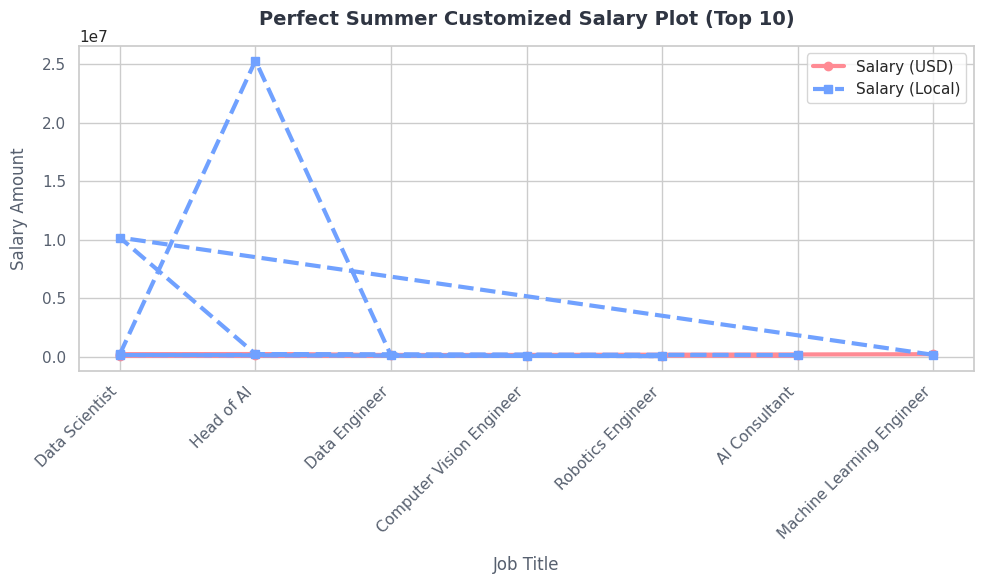

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

df_head10 = df.head(10)
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 6))
plt.plot(df_head10['job_title'], df_head10['salary_usd'],
         color='#FF8B94', linewidth=3, marker='o', markersize=6, label='Salary (USD)')
#اقارن بين 2
plt.plot(df_head10['job_title'], df_head10['salary_local'],
         color='#70A1FF', linewidth=3, linestyle='--', marker='s', markersize=6, label='Salary (Local)')

plt.title('Perfect Summer Customized Salary Plot (Top 10)', fontsize=14, fontweight='bold', pad=15, color='#2F3542')
plt.xlabel('Job Title', fontsize=12, labelpad=10, color='#57606F')
plt.ylabel('Salary Amount', fontsize=12, labelpad=10, color='#57606F')

plt.xticks(rotation=45, ha='right', color='#57606F')
plt.yticks(color='#57606F')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

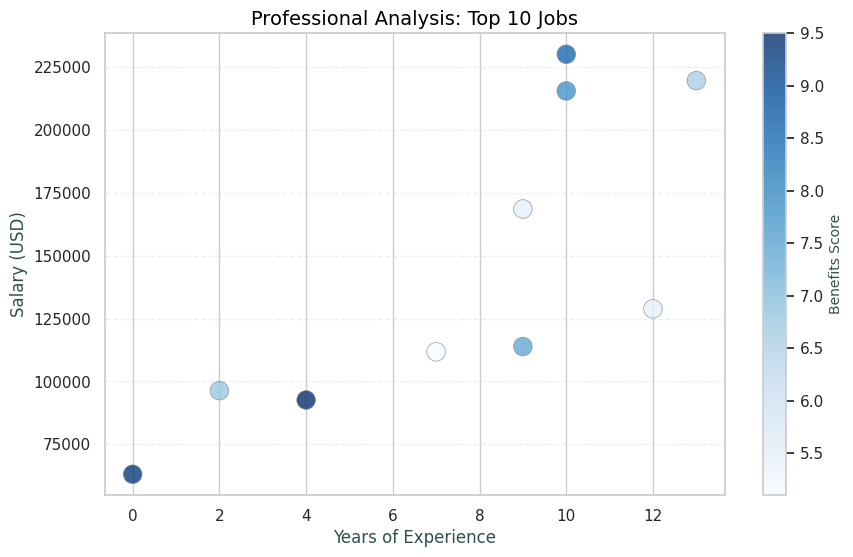

In [18]:
df_top10 = df.head(10)
# 2. إنشاء الرسم البياني بألوان رايقة (Blues)
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df_top10["years_experience"], df_top10["salary_usd"],
                      c=df_top10["benefits_score"], cmap="Blues", s=180,
                      edgecolors='gray', linewidth=0.5, alpha=0.8)
cbar = plt.colorbar(scatter)

cbar.set_label("Benefits Score", fontsize=10, color='darkslategray')
plt.xlabel("Years of Experience", fontsize=12, color='darkslategray')
plt.ylabel("Salary (USD)", fontsize=12, color='darkslategray')
plt.title("Professional Analysis: Top 10 Jobs", fontsize=14, fontweight='light', color='black')


plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.show()

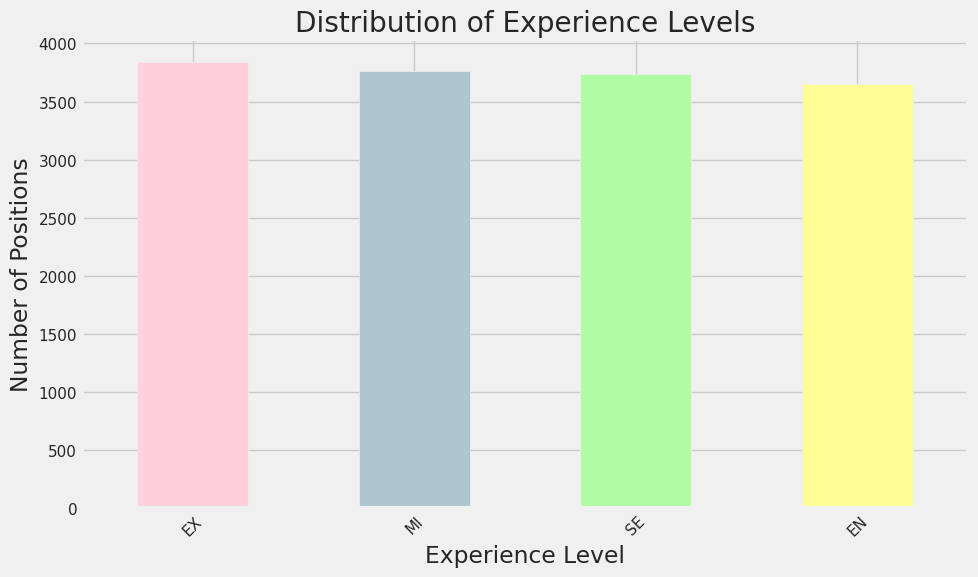

In [27]:

plt.style.use("fivethirtyeight")

# تحضير البيانات
exp_counts = df['experience_level'].value_counts()

# رسم المخطط بألوان صيفية ناعمة
plt.figure(figsize=(10, 6))
exp_counts.plot(kind='bar', color=['#FFD1DC', '#AEC6CF', '#B2FBA5', '#FDFD96'])
plt.title("Distribution of Experience Levels")
plt.xlabel("Experience Level")
plt.ylabel("Number of Positions")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

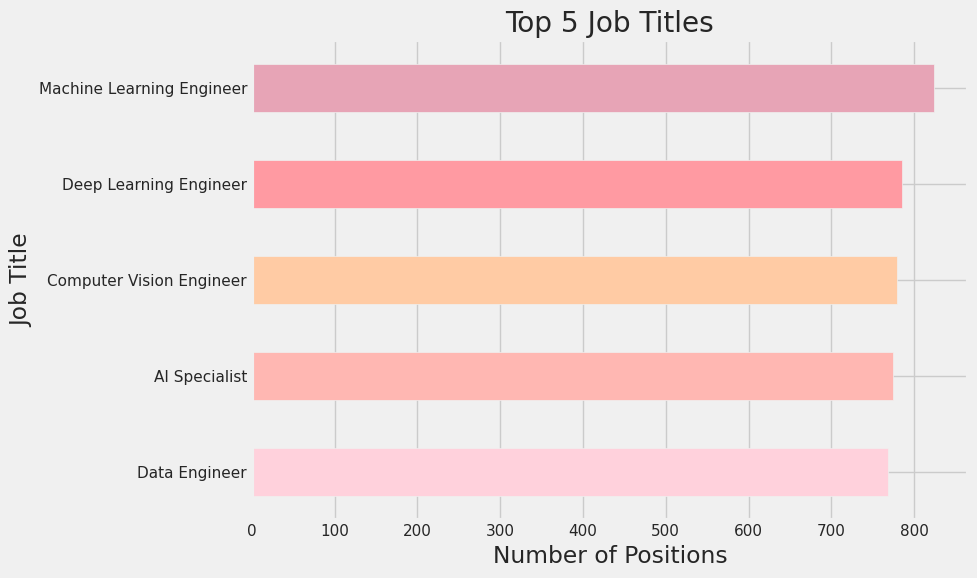

In [22]:

plt.style.use("fivethirtyeight")

# تحضير البيانات: جلب أكثر 5 مسميات وظيفية تكراراً
top_jobs = df['job_title'].value_counts().head(5)

# تعريف تدرجات الزهري الناعم الصيفي
pastel_pink_shades = ['#FFD1DC', '#FFB7B2', '#FFCBA4', '#FF9AA2', '#E7A4B6']

# رسم المخطط الأفقي
plt.figure(figsize=(10, 6))
top_jobs.sort_values().plot(kind='barh', color=pastel_pink_shades)

# إضافة تفاصيل المخطط
plt.title("Top 5 Job Titles")
plt.xlabel("Number of Positions")
plt.ylabel("Job Title")
plt.tight_layout()

# عرض الرسم
plt.show()

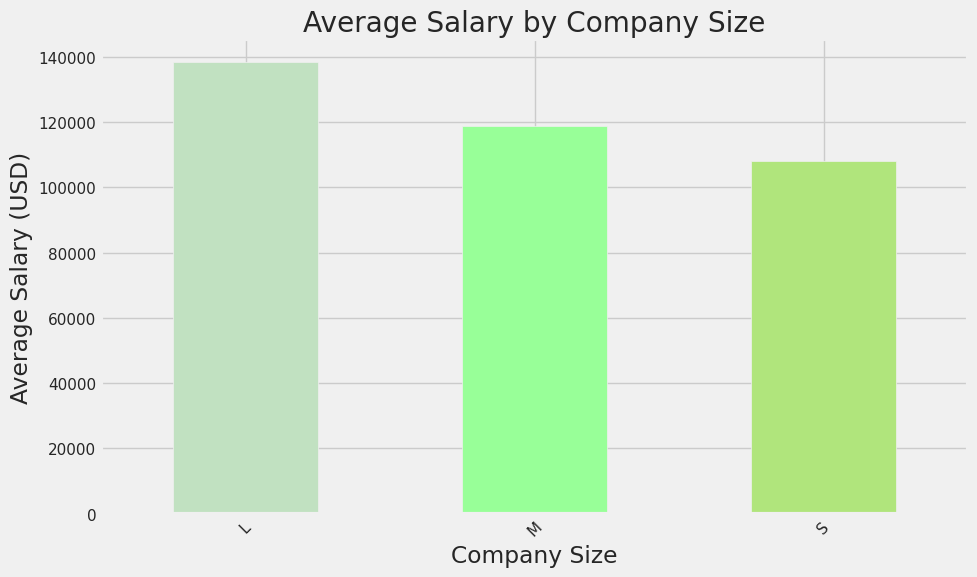

In [26]:

plt.style.use("fivethirtyeight")

# تحضير البيانات: حساب متوسط الرواتب حسب حجم الشركة
salary_by_size = df.groupby('company_size')['salary_usd'].mean()

# تعريف تدرجات الأخضر الهادئ الناعم جداً (لتعطي مظهراً راقياً)
soft_green_shades = ['#C1E1C1', '#98FF98', '#B0E57C', '#77DD77']

# رسم المخطط بألوان الأخضر المختارة
plt.figure(figsize=(10, 6))
salary_by_size.plot(kind='bar', color=soft_green_shades)

# إضافة تفاصيل المخطط
plt.title("Average Salary by Company Size")
plt.xlabel("Company Size")
plt.ylabel("Average Salary (USD)")
plt.xticks(rotation=45)

plt.tight_layout()

# عرض الرسم
plt.show()

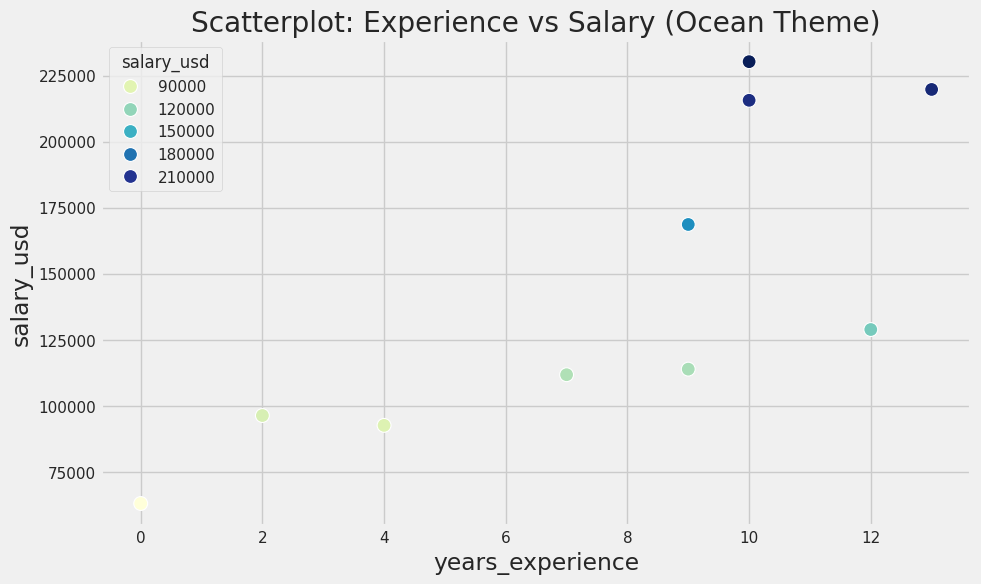

In [29]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv('ai_job_dataset1 (1).csv')
df_head = df.head(10)

plt.figure(figsize=(10, 6))
# استخدام palette بحرية
sns.scatterplot(data=df_head, x='years_experience', y='salary_usd', hue='salary_usd', palette='YlGnBu', s=100)
plt.title('Scatterplot: Experience vs Salary (Ocean Theme)')
plt.show()

/tmp/ipykernel_2390/478362942.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_head, x='experience_level', y='salary_usd', palette='ocean')


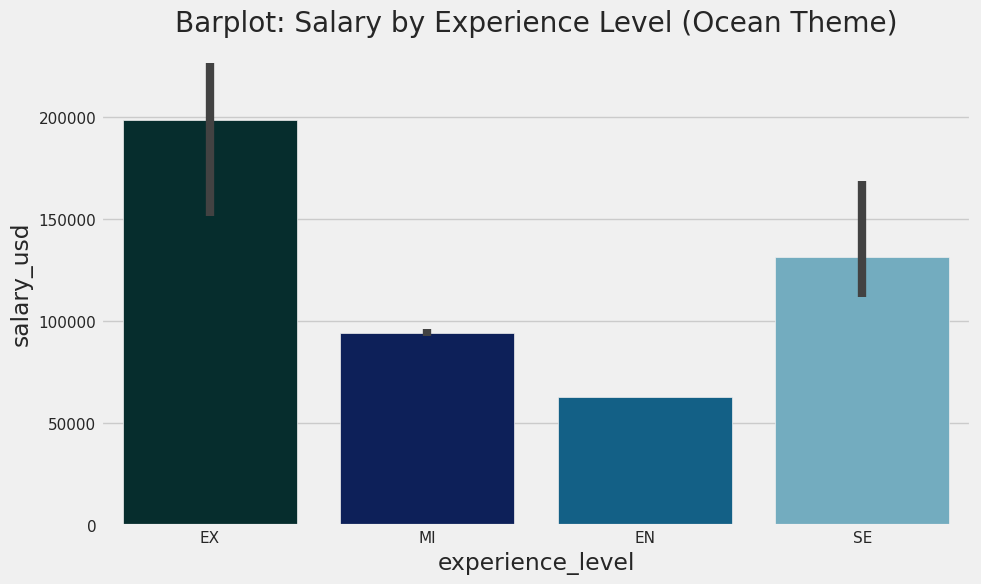

In [30]:
plt.figure(figsize=(10, 6))
# palette 'ocean' تعطي تدرج أزرق بحري فخم
sns.barplot(data=df_head, x='experience_level', y='salary_usd', palette='ocean')
plt.title('Barplot: Salary by Experience Level (Ocean Theme)')
plt.show()

/tmp/ipykernel_2390/2096343068.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_head, y='salary_usd', palette='cubehelix')


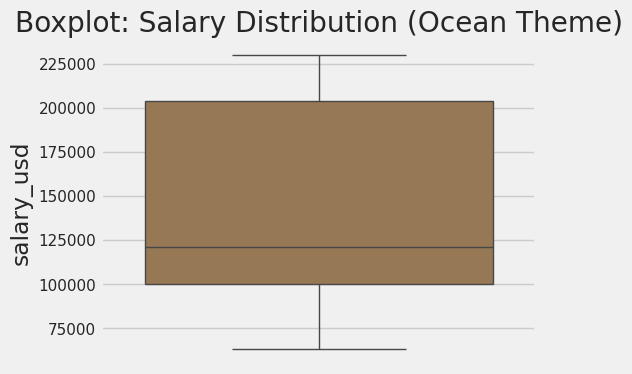

In [33]:
plt.figure(figsize=(5, 4))
# palette 'cubehelix' تعطي تدرجات عميقة وفخمة
sns.boxplot(data=df_head, y='salary_usd', palette='cubehelix')
plt.title('Boxplot: Salary Distribution (Ocean Theme)')
plt.show()

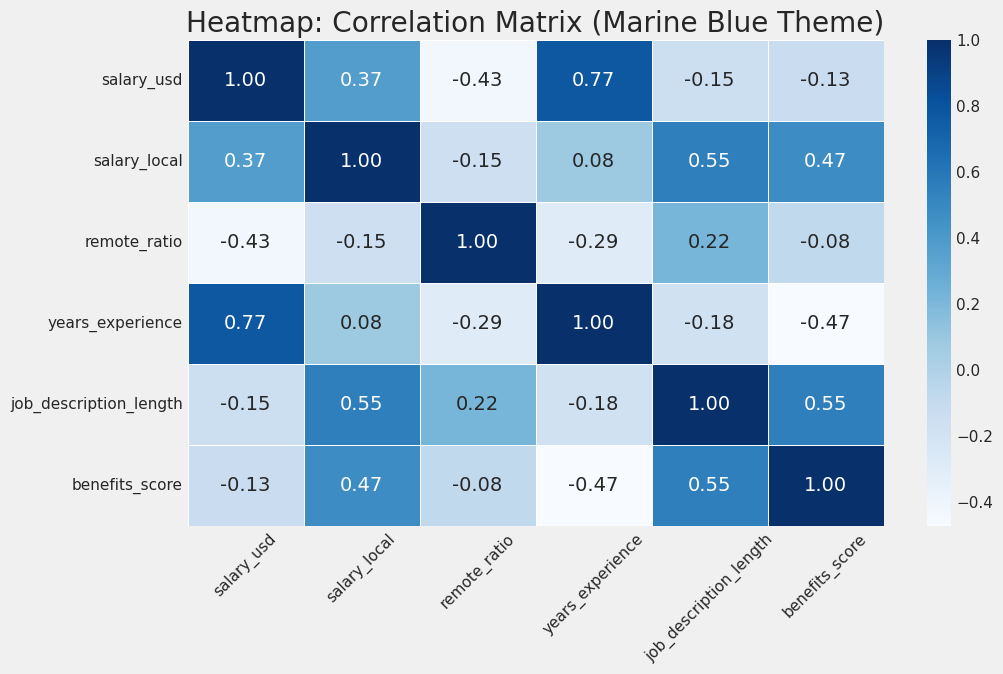

In [41]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# تحميل البيانات
df = pd.read_csv('ai_job_dataset1 (1).csv')
df_head = df.head(10)

plt.figure(figsize=(10, 6))

# اختيار الأعمدة الرقمية
numeric_cols = df_head.select_dtypes(include=['number'])

# تغيير الـ cmap إلى 'Blues' للحصول على تدرجات الأزرق البحري
# قمنا بإضافة as_cmap=True إذا أردت تخصيص المزيد، لكن 'Blues' كافٍ هنا
sns.heatmap(numeric_cols.corr(), annot=True, cmap='Blues', fmt=".2f", linewidths=.5)

plt.xticks(rotation=45)
plt.title('Heatmap: Correlation Matrix (Marine Blue Theme)')
plt.show()

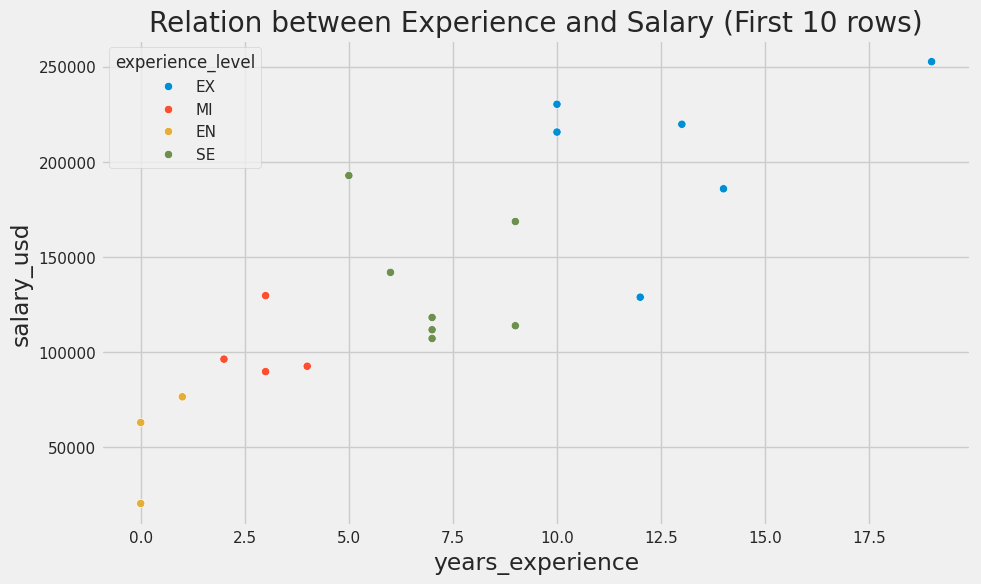

In [52]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
df_head = df.head(20)
plt.figure(figsize=(10, 6))
sns.scatterplot(x="years_experience", y="salary_usd", data=df_head, hue="experience_level")
plt.title("Relation between Experience and Salary (First 10 rows)")
plt.show()

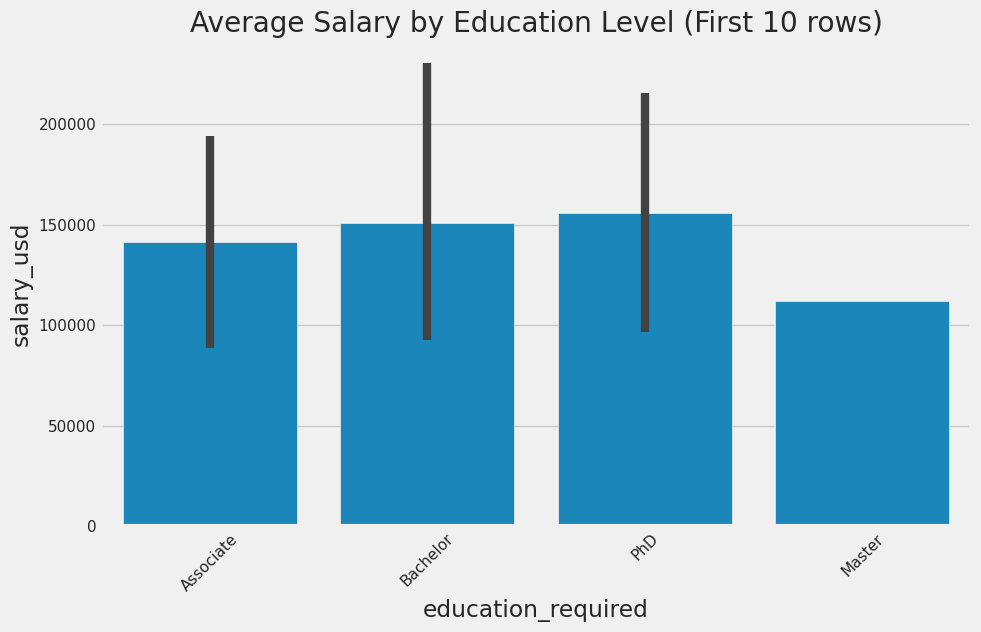

In [53]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# تحميل البيانات وتحديد أول 10 صفوف
df = pd.read_csv('ai_job_dataset1 (1).csv')
df_head = df.head(10)

# إعداد الرسم البياني
plt.figure(figsize=(10, 6))

# استخدام البيانات المحدودة (df_head)
sns.barplot(x="education_required", y="salary_usd", data=df_head)

# التنسيقات
plt.title("Average Salary by Education Level (First 10 rows)")
plt.xticks(rotation=45)
plt.show()

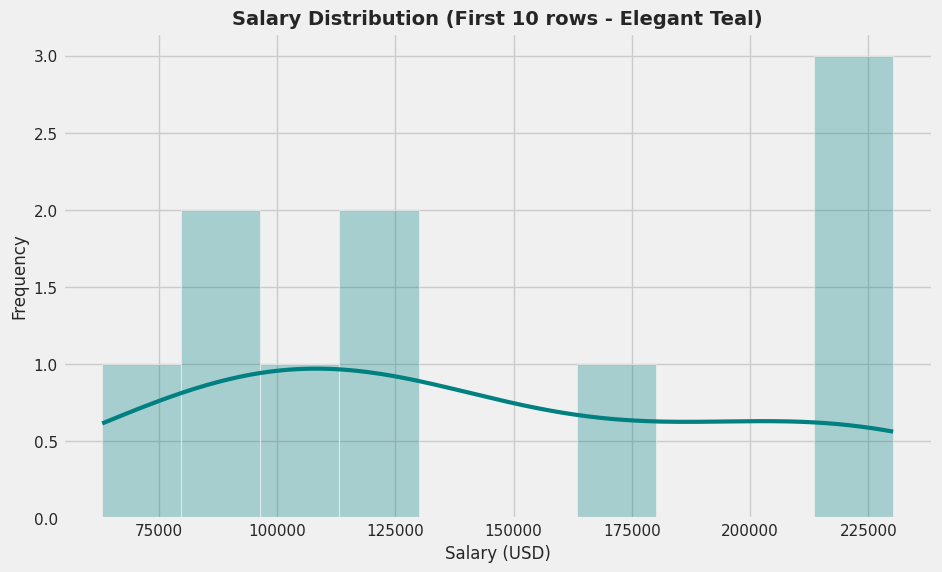

In [55]:

df_head = df.head(10)

plt.figure(figsize=(10, 6))

sns.histplot(df_head["salary_usd"], bins=10, kde=True, color='#008080',
             line_kws={'linewidth': 3}, alpha=0.3)

plt.title("Salary Distribution (First 10 rows - Elegant Teal)", fontsize=14, fontweight='bold')
plt.xlabel("Salary (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.show()

In [59]:
import pandas as pd
import numpy as np
import statistics as st

# 1. تحميل البيانات
df = pd.read_csv('/content/ai_job_dataset1 (1).csv')

# 2. تحديد العمود المراد تحليله (مثلاً الرواتب)
# نستخدم أول 10 صفوف كما طلبتِ سابقاً
data = df['salary_usd'].head(10)

# 3. حساب الإحصائيات
print("--- Statistics for Salary (First 10 rows) ---")
print("Mean salary: ", np.mean(data))
print("Median salary: ", np.median(data))
print("Standard deviation:", np.std(data))
print("Minimum salary: ", np.min(data))
print("Maximum salary: ", np.max(data))

# ملاحظة: st.mode قد يعطي خطأ إذا لم تتكرر قيمة، لذا نستخدم معالجة بسيطة
try:
    print("Most frequent salary: ", st.mode(data))
except st.StatisticsError:
    print("Most frequent salary: No unique mode found (all values are distinct)")

--- Statistics for Salary (First 10 rows) ---
Mean salary:  144085.0
Median salary:  121393.5
Standard deviation: 57044.9821632017
Minimum salary:  63065
Maximum salary:  230237
Most frequent salary:  219728


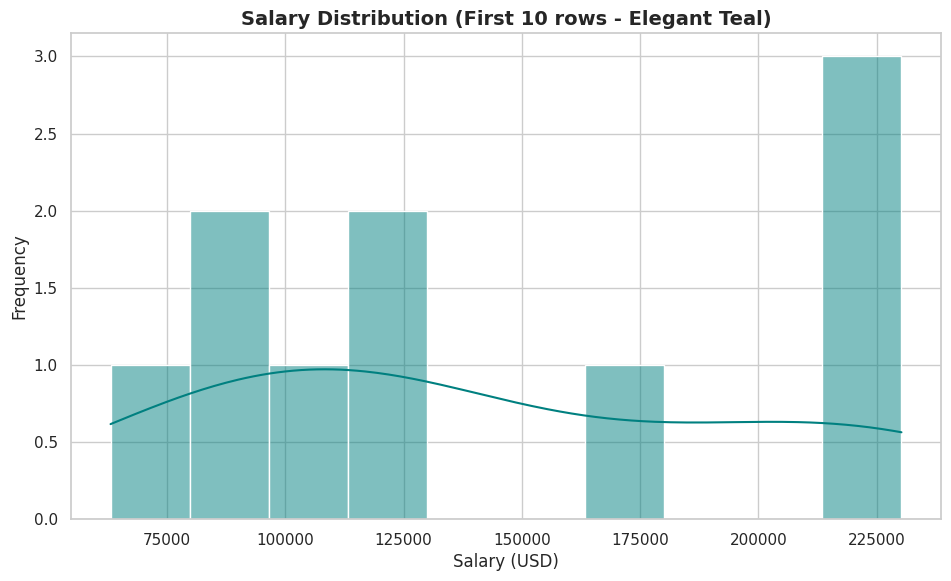

In [63]:


# 2. تحديد أول 10 صفوف فقط
df_head = df.head(10)

# 3. إعداد الرسم البياني بتنسيق احترافي
plt.figure(figsize=(10, 6))

# استخدام لون 'teal' (أزرق بحري) وضبط عدد الـ bins ليكون منطقياً مع 10 صفوف
sns.histplot(df_head["salary_usd"], kde=True, color='#008080', bins=10, edgecolor='white')

# 4. إضافة لمسات تجميلية للرسم
plt.title("Salary Distribution (First 10 rows - Elegant Teal)", fontsize=14, fontweight='bold')
plt.xlabel("Salary (USD)", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

# إظهار الرسم
plt.show()